# Business Evaluation
This notebook evaluation the implemented data science solution and whether it even improve any thing over layman and naive approaches.

## Initial Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score, average_precision_score

In [2]:
train_df = pd.read_parquet('../data/interim/new-features/train.parquet')
test_df = pd.read_parquet('../data/interim/new-features/test.parquet')

Xtrain = train_df.drop('Churned', axis=1)
Xtest = test_df.drop('Churned', axis=1)

ytrain = train_df['Churned']
ytest = test_df['Churned']

In [3]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(Xtrain, ytrain)

ypred = xgb.predict(Xtest)
yprob = xgb.predict_proba(Xtest)

print('', recall_score(ytest, ypred))

 0.7872634979233964


## Customer Segmentation

In [4]:
ltv = train_df['Lifetime_Value']
print("top 1% -", ltv.quantile((1-0.01)))
print("top 5% -", ltv.quantile((1-0.05)))
print("top 10% -", ltv.quantile((1-0.1)))
print("top 25% -", ltv.quantile((1-0.25)))
print()

print("middle ground -", ltv.quantile(0.5))
print("bottom 25% -", ltv.quantile(0.25))

top 1% - 4411.0070000000005
top 5% - 3193.58
top 10% - 2645.885
top 25% - 1882.2925

middle ground - 1242.0749999999998
bottom 25% - 791.095


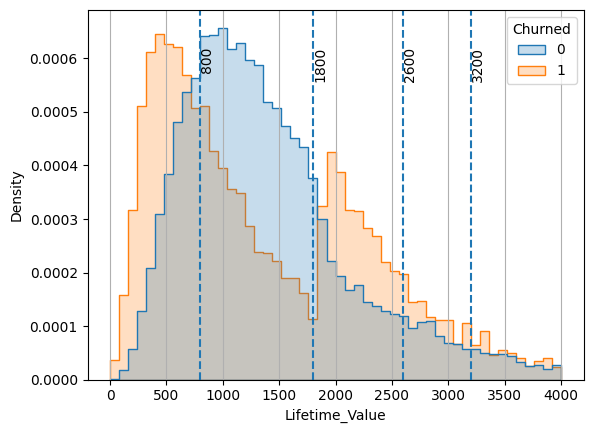

In [5]:
limits = [800, 1800, 2600, 3200]

ax = sns.histplot(
    train_df.query('Lifetime_Value < 4000'),
    x='Lifetime_Value',
    hue='Churned',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)

# Keep regular ticks every 500
ax.xaxis.set_major_locator(mticker.MultipleLocator(500))

# Add vertical lines at your limits
for t in limits:
    ax.axvline(t, linestyle='--')
    ax.text(t, ax.get_ylim()[1]*0.9, f'{t}', rotation=90, va='top')
    
ax.grid(axis='x')
plt.show()

C:\Users\Monika\AppData\Local\Temp\ipykernel_7572\962854464.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = train_df.groupby('lv_bin')['Churned'].mean()


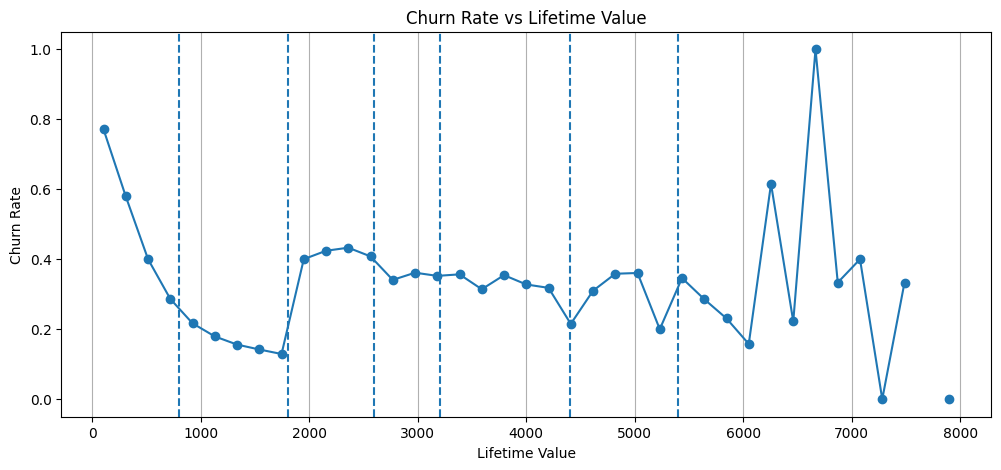

In [6]:
bins = np.linspace(0, 8000, 40)
train_df['lv_bin'] = pd.cut(train_df['Lifetime_Value'], bins=bins)

# churn rate per bin
churn_rate = train_df.groupby('lv_bin')['Churned'].mean()

# midpoints for plotting
x = [interval.mid for interval in churn_rate.index]

plt.figure(figsize=(12,5))
plt.plot(x, churn_rate, marker='o')

# your thresholds
for t in [800, 1800, 2600, 3200, 4400, 5400]:
    plt.axvline(t, linestyle='--')

plt.xlabel("Lifetime Value")
plt.ylabel("Churn Rate")
plt.title("Churn Rate vs Lifetime Value")
plt.grid(axis='x')
plt.show()

In [7]:
def churn_by_bins(bins):
    seg = pd.cut(train_df['Lifetime_Value'], bins=bins, right=False)
    return pd.crosstab(seg, train_df['Churned'], normalize='index')[1]

bin1_churn = churn_by_bins([0, 800, 1800, 2600, np.inf])
bin2_churn = churn_by_bins([0, 800, 1800, 2700, np.inf])
bin3_churn = churn_by_bins([0, 800, 1800, 3200, np.inf])
bin4_churn = churn_by_bins([0, 800, 1800, 2600, 4400, np.inf])
bin5_churn = churn_by_bins([0, 800, 1800, 3200, 4400, np.inf])


pd.concat([bin1_churn, bin2_churn, bin3_churn, bin4_churn, bin5_churn], axis=1, keys=['Bin1', 'Bin2', 'Bin3', 'Bin4', 'Bin5'])

,Bin1,Bin2,Bin3,Bin4,Bin5
Lifetime_Value,,,,,
"[0.0, 800.0)",0.410101,0.410101,0.410101,0.410101,0.410101
"[800.0, 1800.0)",0.174503,0.174503,0.174503,0.174503,0.174503
"[1800.0, 2600.0)",0.389236,NaN,NaN,0.389236,NaN
"[2600.0, inf)",0.345739,NaN,NaN,NaN,NaN
"[1800.0, 2700.0)",NaN,0.389003,NaN,NaN,NaN
"[2700.0, inf)",NaN,0.340633,NaN,NaN,NaN
"[1800.0, 3200.0)",NaN,NaN,0.382736,NaN,0.382736
"[3200.0, inf)",NaN,NaN,0.325836,NaN,NaN
"[2600.0, 4400.0)",NaN,NaN,NaN,0.349344,NaN


Based on quantile and distribution, following segments are considered:
| Segment | Range              | Represents                     |
|--------|--------------------|--------------------------------|
| Low    | 0 – 800            | Bottom 25%                    |
| Medium | 800 – 1800         | 25th to 75th percentile       |
| High   | 1800 – 2600        | 75th to 90th percentile       |
| IMP    | 2600 – 4400        | 90th to 99th percentile       |
| VIP    | 4400+              | Top 1%                        |

3200 stays in the middle of the cuttoff and `churn rate vs ltv` plot shows ongoing trend in churn rate.

In [8]:
bins = [0, 800, 1800, 2600, 4400, np.inf]
labels = ['Low', 'Medium', 'High', 'IMP', 'VIP']

ltv_segments = pd.cut(
    train_df['Lifetime_Value'],
    bins=bins,
    labels=labels,
    right=False  # makes intervals like [800, 1800)
)

pd.crosstab(
    ltv_segments,
    train_df['Churned'],
    normalize='index'
)

Churned,0,1
Lifetime_Value,,
Low,0.589899,0.410101
Medium,0.825497,0.174503
High,0.610764,0.389236
IMP,0.650656,0.349344
VIP,0.688202,0.311798


## Business Retention Evaluation

This section show whether the churn model improves business outcomes over naive and non-ML approaches.

We compare five approaches on the same test set:

- A1 Random: spend the same fixed budget on randomly chosen customers.
- A2 Segment Priority: no model and no churn statistics, just intervene in business-priority order `VIP -> IMP -> High -> Medium -> Low` until the budget is exhausted.
- A3 Statistical and Segment: use historical churn rate by LTV segment together with business segment priority, but no churn model.
- A4 Naive Predictive ML: use churn probability only, with one flat cutoff for everyone.
- A5 Predictive ML with LTV Segments: lower the threshold for higher-value segments and rank by churn probability times LTV.


A1, A2, A3, A4, and A5 share the same intervention budget so the comparison stays fair.


### config and func setup

In [9]:
best_model = xgb

# ------------------------------ business config ----------------------------- #
INTERVENTION_COST = 200
SAVE_RATE = 0.30
BUDGET_FRAC = 0.50
BUDGET_K = int(round(len(Xtest) * BUDGET_FRAC))

# --------------------- test set for approach evaluation --------------------- #
seg_bins = [0, 800, 1800, 2600, 4400, np.inf]
seg_labels = ['Low', 'Medium', 'High', 'IMP', 'VIP']

eval_df = Xtest[['Lifetime_Value']].copy()
eval_df['churn'] = ytest.values
eval_df['proba'] = yprob[:, 1]
eval_df['segment'] = pd.cut(
    eval_df['Lifetime_Value'],
    bins=seg_bins,
    labels=seg_labels,
    right=False
)

# ------------------------- known set for comparision ------------------------ #
train_segments = pd.cut(
    train_df['Lifetime_Value'],
    bins=seg_bins,
    labels=seg_labels,
    right=False
)
seg_churn_rate = train_df.groupby(train_segments, observed=True)['Churned'].mean()
eval_df['seg_churn_rate'] = eval_df['segment'].map(seg_churn_rate).astype(float)


print(f'Budgeted interventions: {BUDGET_K} customers ({BUDGET_FRAC:.0%} of test set)')
eval_df.groupby('segment', observed=True).agg(
    customers=('churn', 'size'),
    avg_ltv=('Lifetime_Value', 'mean'),
    eval_churn_rate=('churn', 'mean'),
    train_churn_rate=('seg_churn_rate', 'first')
).round(3)

Budgeted interventions: 7497 customers (50% of test set)


,customers,avg_ltv,eval_churn_rate,train_churn_rate
segment,,,,
Low,3853,540.101,0.406,0.410
Medium,7140,1252.916,0.177,0.175
High,2475,2138.291,0.398,0.389
IMP,1365,3205.094,0.349,0.349
VIP,161,5187.650,0.280,0.312


In [10]:
def top_k_mask(score, k):
    mask = pd.Series(False, index=score.index)
    mask.loc[score.nlargest(k).index] = True
    return mask.to_numpy()

def selected_segment_mix(action_mask):
    mask = np.asarray(action_mask, dtype=bool)
    return eval_df.loc[mask, 'segment'].value_counts().reindex(seg_labels, fill_value=0)

def business_metrics(action_mask, label):
    df = eval_df.copy()
    df['action'] = np.asarray(action_mask, dtype=bool)

    churn_mask = df['churn'] == 1
    caught_mask = df['action'] & churn_mask
    missed_mask = ~df['action'] & churn_mask

    potential_clv_loss = df.loc[churn_mask, 'Lifetime_Value'].sum()
    clv_protected = df.loc[caught_mask, 'Lifetime_Value'].sum() * SAVE_RATE
    clv_missed = df.loc[missed_mask, 'Lifetime_Value'].sum()
    remaining_loss = potential_clv_loss - clv_protected
    intervention_cost = df['action'].sum() * INTERVENTION_COST
    net_value = clv_protected - intervention_cost

    result = {
        'Approach': label,
        'Intervened': int(df['action'].sum()),
        'Intervention Cost': int(intervention_cost),
        'Potential CLV Loss': int(potential_clv_loss),
        'CLV Protected': int(clv_protected),
        'CLV Missed': int(clv_missed),
        'Remaining Loss': int(remaining_loss),
        'Net Value': int(net_value),
    }

    for seg in seg_labels:
        seg_mask = df['segment'] == seg
        total_churners = (seg_mask & churn_mask).sum()
        if total_churners == 0:
            result[f'Recall {seg}'] = np.nan
        else:
            result[f'Recall {seg}'] = round((caught_mask & seg_mask).sum() / total_churners, 3)

    return result

### Random Intervene

In [11]:
rng = np.random.default_rng(42)

random_idx = rng.choice(eval_df.index.to_numpy(), size=BUDGET_K, replace=False)
action_a1 = eval_df.index.isin(random_idx)

selected_segment_mix(action_a1)


segment
Low       1939
Medium    3479
High      1288
IMP        710
VIP         81
Name: count, dtype: int64

### Segment Priority

In [12]:
segment_priority = ['VIP', 'IMP', 'High', 'Medium', 'Low']
priority_rank = {segment: rank for rank, segment in enumerate(segment_priority)}

a2_rank = eval_df[['segment', 'Lifetime_Value']].copy()
a2_rank['segment_rank'] = a2_rank['segment'].astype(str).map(priority_rank)
a2_rank = a2_rank.sort_values(
    ['segment_rank', 'Lifetime_Value'],
    ascending=[True, False]
)

action_a2 = eval_df.index.isin(a2_rank.head(BUDGET_K).index)

selected_segment_mix(action_a2)


segment
Low          0
Medium    3496
High      2475
IMP       1365
VIP        161
Name: count, dtype: int64

### Statistical and CLV based Retention

In [13]:
stats_rank = eval_df[['segment', 'seg_churn_rate', 'Lifetime_Value']].copy()
stats_rank['segment_rank'] = stats_rank['segment'].astype(str).map(priority_rank)
stats_rank = stats_rank.sort_values(
    ['seg_churn_rate', 'segment_rank', 'Lifetime_Value'],
    ascending=[False, True, False]
)

action_a3 = eval_df.index.isin(stats_rank.head(BUDGET_K).index)

selected_segment_mix(action_a3)


segment
Low       3853
Medium       0
High      2475
IMP       1169
VIP          0
Name: count, dtype: int64

### ML Model based Retention

In [14]:
action_a4 = top_k_mask(eval_df['proba'], BUDGET_K)
flat_threshold = eval_df.loc[action_a4, 'proba'].min()

print(f'Flat probability cutoff used by A4: {flat_threshold:.4f}')
selected_segment_mix(action_a4)


Flat probability cutoff used by A4: 0.0594


segment
Low       2631
Medium    2846
High      1322
IMP        625
VIP         73
Name: count, dtype: int64

### Churn Prediction with segment priority

In [15]:
segment_thresholds = {
    'Low': 0.70,
    'Medium': 0.45,
    'High': 0.28,
    'IMP': 0.18,
    'VIP': 0.10,
}

eval_df['segment_threshold'] = eval_df['segment'].astype(str).map(segment_thresholds)
eval_df['priority_score'] = eval_df['proba'] * eval_df['Lifetime_Value']

eligible_a5 = eval_df['proba'] >= eval_df['segment_threshold']
eligible_idx = eval_df.loc[eligible_a5].sort_values(
    'priority_score',
    ascending=False
).index.tolist()
remaining_idx = eval_df.loc[~eval_df.index.isin(eligible_idx)].sort_values(
    'priority_score',
    ascending=False
).index.tolist()

selected_idx = eligible_idx[:BUDGET_K]
if len(selected_idx) < BUDGET_K:
    selected_idx += remaining_idx[:BUDGET_K - len(selected_idx)]

action_a5 = eval_df.index.isin(selected_idx)

pd.DataFrame({
    'threshold': pd.Series(segment_thresholds).reindex(seg_labels),
    'selected_customers': selected_segment_mix(action_a5).to_list(),
}, index=seg_labels)


,threshold,selected_customers
Low,0.70,2093
Medium,0.45,2702
High,0.28,1650
IMP,0.18,933
VIP,0.10,119


### Comparision

In [18]:
results = pd.DataFrame([
    business_metrics(action_a1, 'A1 Random'),
    business_metrics(action_a2, 'A2 Segment Priority'),
    business_metrics(action_a3, 'A3 Statistical and Segment'),
    business_metrics(action_a4, 'A4 Naive Predictive ML'),
    business_metrics(action_a5, 'A5 Predictive ML + CLV Segments'),
]).set_index('Approach')

results[[
    'Intervened',
    'Intervention Cost',
    'CLV Protected',
    'CLV Missed',
    'Remaining Loss',
    'Net Value',
    'Recall Low',
    'Recall High',
    'Recall IMP',
    'Recall VIP',
]].round(3)


,Intervened,Intervention Cost,CLV Protected,CLV Missed,Remaining Loss,Net Value,Recall Low,Recall High,Recall IMP,Recall VIP
Approach,,,,,,,,,,
A1 Random,7497,1499400,942387,2995773,5194678,-557012,0.492,0.523,0.528,0.489
A2 Segment Priority,7497,1499400,1393992,1490423,4743073,-105407,0.000,1.000,1.000,1.000
A3 Statistical and Segment,7497,1499400,1268719,1908000,4868346,-230680,1.000,1.000,0.870,0.000
A4 Naive Predictive ML,7497,1499400,1668380,575799,4468686,168980,0.955,0.945,0.922,0.911
A5 Predictive ML + CLV Segments,7497,1499400,1685472,518823,4451593,186072,0.912,0.953,0.958,0.956


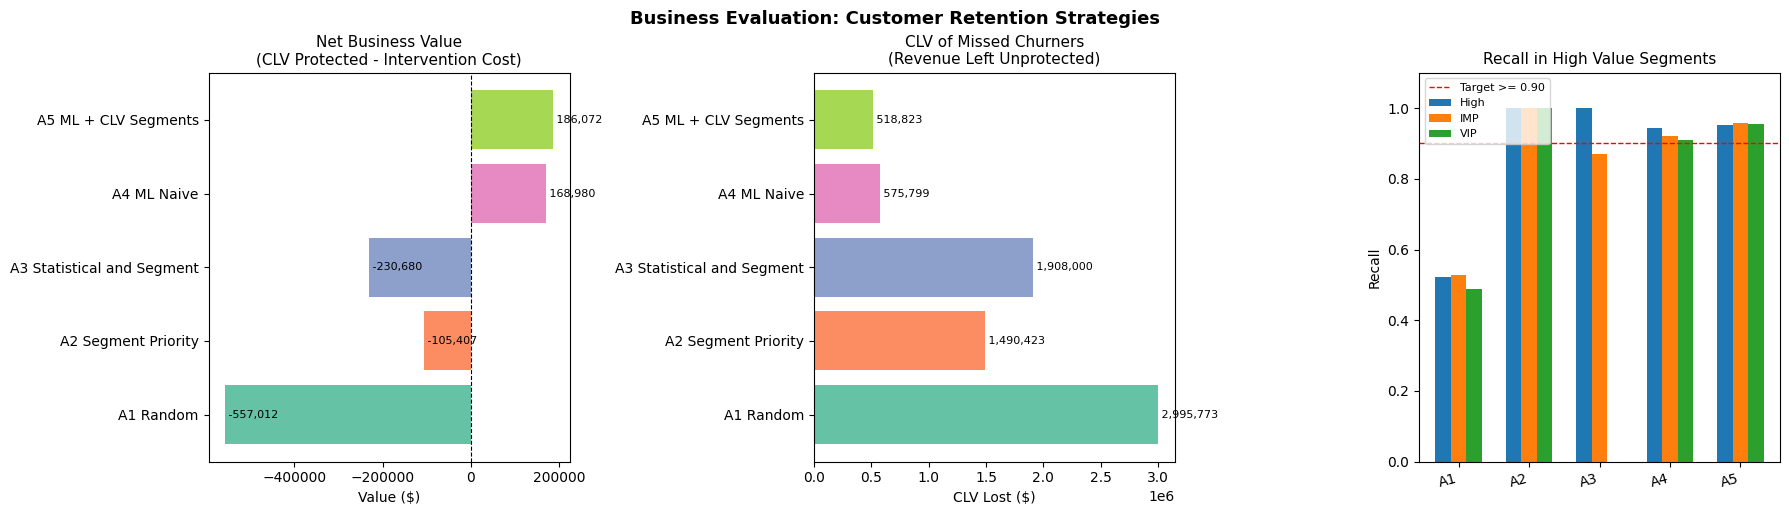

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
approaches = results.index.tolist()
palette = sns.color_palette('Set2', n_colors=len(approaches))

axes[0].barh(approaches, results['Net Value'], color=palette)
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Net Business Value\n(CLV Protected - Intervention Cost)', fontsize=11)
axes[0].set_xlabel('Value ($)')
for i, value in enumerate(results['Net Value']):
    axes[0].text(value, i, f' {value:,.0f}', va='center', fontsize=8)

axes[1].barh(approaches, results['CLV Missed'], color=palette)
axes[1].set_title('CLV of Missed Churners\n(Revenue Left Unprotected)', fontsize=11)
axes[1].set_xlabel('CLV Lost ($)')
for i, value in enumerate(results['CLV Missed']):
    axes[1].text(value, i, f' {value:,.0f}', va='center', fontsize=8)

recall_cols = ['Recall High', 'Recall IMP', 'Recall VIP']
x = np.arange(len(approaches))
width = 0.22
for i, col in enumerate(recall_cols):
    axes[2].bar(x + i * width, results[col].fillna(0), width, label=col.replace('Recall ', ''))

axes[2].axhline(0.9, color='red', ls='--', lw=1, label='Target >= 0.90')
axes[2].set_xticks(x + width)
axes[2].set_xticklabels([name.split()[0] for name in approaches], rotation=15, ha='right')
axes[2].set_title('Recall in High Value Segments', fontsize=11)
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1.1)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Business Evaluation: Customer Retention Strategies', fontsize=13, y=1.02, fontweight='bold')
plt.show()


## Summary

Once you run this, the narrative should be clear:

| Approach | What it reveals |
| --- | --- |
| A1 Random | Catches churners by luck. The budget is spread without regard to churn risk or customer value. |
| A2 Segment Priority | This is a simple business rule with no data science: protect VIP first, then IMP, then High, then Medium, then Low until the budget runs out. |
| A3 Statistical and Segment | This uses historical churn rate plus business segment priority. It is more sensible than a random tie-breaker, but it still treats everyone inside a segment the same and uses no individual churn prediction. |
| A4 Naive Predictive ML | This is the first real DS gain. Ranking by churn probability improves net value and reduces missed CLV, but the same cutoff is still applied to Low and VIP customers. |
| A5 Predictive ML with CLV Segments | This is the business-aware policy. High, IMP, and VIP customers get more aggressive treatment, high-value recall stays strong, and missed CLV falls further. |

This validates that the churn model improved business outcomes, and combining it with the LTV metric delivered a reasonably significant improvement in retention performance.